<a href="https://colab.research.google.com/github/konul-aliyeva/DeepLearning/blob/main/Introduction_to_DeepLearning_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
A = torch.tensor([
    [1.0, 4.0, 7.0],
    [2.0, 3.0, 6.0]
])


In [ ]:
A


tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [ ]:
X =torch.tensor([
    [1.0, 4.0, 7.0],
    [2.0, 3.0, 6.0]
], dtype=torch.bfloat16)


In [ ]:
X

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.bfloat16)

In [ ]:
X.shape

torch.Size([2, 3])

In [ ]:
X.dtype

torch.bfloat16

NumPy array-ində olduğu kimi, **indexing** və **slicing**-dən istifadə edərək bir tensor-u *in place* dəyişdirə bilərik.

In [ ]:
X[0, 1]

tensor(4., dtype=torch.bfloat16)

In [ ]:
X[:, 1]

tensor([4., 3.], dtype=torch.bfloat16)

In [ ]:
X[:, 1]= -99
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X.abs()

tensor([[ 1., 99.,  7.],
        [ 2., 99.,  6.]], dtype=torch.bfloat16)

In [ ]:
torch.abs(X)

tensor([[ 1., 99.,  7.],
        [ 2., 99.,  6.]], dtype=torch.bfloat16)

In [ ]:
# torch.cos(), torch.exp(), torch.max(), torch.mean()

X.sqrt()

tensor([[1.0000,    nan, 2.6406],
        [1.4141,    nan, 2.4531]], dtype=torch.bfloat16)

In [ ]:
10 * (X + 1.0)  # itemwise addition and multiplication

tensor([[  20., -980.,   80.],
        [  30., -980.,   70.]], dtype=torch.bfloat16)

In [ ]:
X.exp()  #torch.exp(X) yazmaq əvəzinə X.exp() yaza bilərik

tensor([[   2.7188,    0.0000, 1096.0000],
        [   7.3750,    0.0000,  404.0000]], dtype=torch.bfloat16)

In [ ]:
X.mean()

tensor(-30.3750, dtype=torch.bfloat16)

In [ ]:
X.max(dim=0)  #keepdim = True
 # max values along dimension 0

torch.return_types.max(
values=tensor([  2., -99.,   7.], dtype=torch.bfloat16),
indices=tensor([1, 0, 0]))

In [ ]:
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X @ X.T

tensor([[9856., 9856.],
        [9856., 9856.]], dtype=torch.bfloat16)

In [ ]:
import numpy as np

In [ ]:
A.numpy()


array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [ ]:
torch.tensor(np.array([[1.,4., 7.,],
                       [2., 3., 6.,]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.float64)

float-lar üçün default precision *PyTorch-da 32 bit* olduğu halda, NumPy-da 64 bitdir. Deep learning sahəsində adətən 32 bit istifadə etmək daha yaxşıdır, çünki bu, yarıbayarı daha az RAM tutur və hesablamaları sürətləndirir; həmçinin neural net-lər real olaraq 64-bit float-ların təqdim etdiyi əlavə precision-a ehtiyac duymur.

In [ ]:
 #automatically converts the array to 32 bits
N = torch.FloatTensor(np.array([
    [1., 4., 7., ],
    [2., 3., 6]
]))

***torch.from_numpy()*** funksiyasından istifadə NumPy array-ini dəyişdirerken həm də tensor-u dəyişdirəcək və ya əksinə.

In [ ]:
N.dtype

torch.float32

In [ ]:
X.relu()  # relu(x)=max(0,x)

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

In [ ]:
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X.relu_()

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

In [ ]:


X  # relu _ underscore changed in place

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

cpu- sequantially  < gpu ise paralel

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else :
  device = "cpu"

In [ ]:
M = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.]
])

M = M.to(device)

cpu() və cuda() method-ları müvafiq olaraq to("cpu") və to("cuda") ifadələrinin qısaldılmış formalarıdır.

In [ ]:
M

tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0')

In [ ]:
M.device

device(type='cuda', index=0)

In [ ]:
M = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.]],device=device)


In [ ]:
R = M @ M.T

In [ ]:
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

In [ ]:
M =torch.rand((1000, 1000 )) # on the CPU
%timeit M @ M.T
M =torch.rand((1000, 1000 ), device='cuda') # on the GPU
%timeit M @ M.T

30.8 ms ± 2.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
657 µs ± 8.46 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
x = torch.tensor(5.0, requires_grad=True)   #
f = x ** 2
f

tensor(25., grad_fn=<PowBackward0>)

In [ ]:
f.backward()
x.grad

tensor(10.)

In [ ]:
learning_rate = 0.1
with torch.no_grad():
  x -= learning_rate * x.grad  #Gradient descent step

In [ ]:
x

tensor(4., requires_grad=True)

In [ ]:
X_detached = x.detach()
X_detached = learning_rate * x.grad

In [ ]:
X_detached

tensor(1.)

In [ ]:
x.grad.zero_()

tensor(0.)

In [ ]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
  f = x ** 2    #forward pass
  f.backward()
  with torch.no_grad():
    x -= learning_rate * x.grad #gradient descent step
    print(x)
    #print(x.grad)

    x.grad.zero_()  # reset the gradients

tensor(4., requires_grad=True)
tensor(3.2000, requires_grad=True)
tensor(2.5600, requires_grad=True)
tensor(2.0480, requires_grad=True)
tensor(1.6384, requires_grad=True)
tensor(1.3107, requires_grad=True)
tensor(1.0486, requires_grad=True)
tensor(0.8389, requires_grad=True)
tensor(0.6711, requires_grad=True)
tensor(0.5369, requires_grad=True)
tensor(0.4295, requires_grad=True)
tensor(0.3436, requires_grad=True)
tensor(0.2749, requires_grad=True)
tensor(0.2199, requires_grad=True)
tensor(0.1759, requires_grad=True)
tensor(0.1407, requires_grad=True)
tensor(0.1126, requires_grad=True)
tensor(0.0901, requires_grad=True)
tensor(0.0721, requires_grad=True)
tensor(0.0576, requires_grad=True)
tensor(0.0461, requires_grad=True)
tensor(0.0369, requires_grad=True)
tensor(0.0295, requires_grad=True)
tensor(0.0236, requires_grad=True)
tensor(0.0189, requires_grad=True)
tensor(0.0151, requires_grad=True)
tensor(0.0121, requires_grad=True)
tensor(0.0097, requires_grad=True)
tensor(0.0077, requires_

In [ ]:
# t = torch.tensor(2.0,requires_grad=True )
# z = t.exp()
# z+=1
# z.backward()

In [ ]:
# but

t = torch.tensor(2.0, requires_grad=True)
z = t.exp()  # this is an intermediate result
z = z + 1  # new tensor created, and previous saved for computation graph
z.backward()

# make sure you don’t modify in place a tensor needed for backprop

In [ ]:
import sklearn

In [ ]:
X,y = sklearn.datasets.fetch_california_housing(return_X_y=True)


In [ ]:
X_train_full, X_test, y_train_full, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2)

In [ ]:
X_train, X_valid, y_train, y_valid = sklearn.model_selection.train_test_split(X_train_full, y_train_full, test_size=0.2)

In [ ]:
X_train.shape, X_valid.shape, X_test.shape

((13209, 8), (3303, 8), (4128, 8))

In [ ]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [ ]:
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)


In [ ]:
torch.manual_seed(42)
n_features = X_train.shape[1]
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [ ]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
  y_pred = X_train @ w + b
  loss = ((y_pred - y_train) ** 2).mean()
  loss.backward()
  with torch.no_grad():
    b -= learning_rate * b.grad
    w -= learning_rate * w.grad
    b.grad.zero_()
    w.grad.zero_()
  print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}')



Epoch 1/20, Loss: 16.147136688232422
Epoch 2/20, Loss: 4.8078718185424805
Epoch 3/20, Loss: 2.1956894397735596
Epoch 4/20, Loss: 1.2945915460586548
Epoch 5/20, Loss: 0.9497848153114319
Epoch 6/20, Loss: 0.8068357110023499
Epoch 7/20, Loss: 0.7402134537696838
Epoch 8/20, Loss: 0.703685462474823
Epoch 9/20, Loss: 0.6798211932182312
Epoch 10/20, Loss: 0.6618901491165161
Epoch 11/20, Loss: 0.6472032070159912
Epoch 12/20, Loss: 0.6346198916435242
Epoch 13/20, Loss: 0.6236047148704529
Epoch 14/20, Loss: 0.6138654947280884
Epoch 15/20, Loss: 0.6052138209342957
Epoch 16/20, Loss: 0.5975098609924316
Epoch 17/20, Loss: 0.5906405448913574
Epoch 18/20, Loss: 0.5845096707344055
Epoch 19/20, Loss: 0.5790337920188904
Epoch 20/20, Loss: 0.5741394758224487


In [ ]:
X_new =  X_test[:3]
with torch.no_grad():
  y_pred = X_new @ w + b

y_pred

tensor([[1.8766],
        [2.8605],
        [2.2395]])

In [ ]:
y_test[:3]

tensor([[3.1090],
        [1.6860],
        [1.4690]])

In [ ]:
import torch.nn as nn

In [ ]:
torch.manual_seed(42)
model = nn.Linear(in_features = n_features, out_features=1)


In [ ]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [ ]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [ ]:
model.parameters()

<generator object Module.parameters at 0x7a4977ad8ac0>

In [ ]:
next(model.parameters())

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [ ]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [ ]:
for name, param in model.named_parameters():
  print(f'{name} |{param}')

weight |Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
bias |Parameter containing:
tensor([0.3117], requires_grad=True)


In [ ]:
model(X_train[:2])

tensor([[0.1710],
        [0.5899]], grad_fn=<AddmmBackward0>)

In [ ]:
y_train[:2]

tensor([[0.8420],
        [2.4710]])

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()

In [ ]:
model(X_train[:2])

tensor([[0.1710],
        [0.5899]], grad_fn=<AddmmBackward0>)

In [ ]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}')

In [ ]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.2890305519104
Epoch 2/20, Loss: 0.7808777689933777
Epoch 3/20, Loss: 0.6276636719703674
Epoch 4/20, Loss: 0.6093279719352722
Epoch 5/20, Loss: 0.5995145440101624
Epoch 6/20, Loss: 0.5916221141815186
Epoch 7/20, Loss: 0.5848315358161926
Epoch 8/20, Loss: 0.5788734555244446
Epoch 9/20, Loss: 0.5736070871353149
Epoch 10/20, Loss: 0.5689374208450317
Epoch 11/20, Loss: 0.5647907257080078
Epoch 12/20, Loss: 0.561104953289032
Epoch 13/20, Loss: 0.5578267574310303
Epoch 14/20, Loss: 0.5549094080924988
Epoch 15/20, Loss: 0.5523116588592529
Epoch 16/20, Loss: 0.5499974489212036
Epoch 17/20, Loss: 0.5479345321655273
Epoch 18/20, Loss: 0.5460945963859558
Epoch 19/20, Loss: 0.5444527268409729
Epoch 20/20, Loss: 0.5429865121841431


In [ ]:
X_new = X_test[:3]

with torch.no_grad():
  y_pred = model(X_new)

y_pred

tensor([[1.9103],
        [2.8452],
        [2.1678]])

In [ ]:
y_test[:3]

tensor([[3.1090],
        [1.6860],
        [1.4690]])

In [ ]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features,50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

In [ ]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.014988422393799
Epoch 2/20, Loss: 2.089120388031006
Epoch 3/20, Loss: 1.0323439836502075
Epoch 4/20, Loss: 0.8817775249481201
Epoch 5/20, Loss: 0.7973483204841614
Epoch 6/20, Loss: 0.7454736232757568
Epoch 7/20, Loss: 0.712356448173523
Epoch 8/20, Loss: 0.6904282569885254
Epoch 9/20, Loss: 0.6751192808151245
Epoch 10/20, Loss: 0.6637426614761353
Epoch 11/20, Loss: 0.6546683311462402
Epoch 12/20, Loss: 0.6469358205795288
Epoch 13/20, Loss: 0.6400569081306458
Epoch 14/20, Loss: 0.6337502002716064
Epoch 15/20, Loss: 0.6278473138809204
Epoch 16/20, Loss: 0.6222549676895142
Epoch 17/20, Loss: 0.6169068217277527
Epoch 18/20, Loss: 0.6117704510688782
Epoch 19/20, Loss: 0.6068169474601746
Epoch 20/20, Loss: 0.6020227074623108


# Making it MiniBatches


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(X_train, y_train)

In [ ]:
train_loader =DataLoader(train_dataset, batch_size=32, shuffle=True)


In [ ]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features= n_features, out_features= 64),
    nn.ReLU(),
    nn.Linear(in_features= 64, out_features= 32),
    nn.ReLU(),
    nn.Linear(in_features= 32, out_features= 1)
)

model.to(device)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr= learning_rate)
mse = nn.MSELoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0.
    for X_batch,y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred =  model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss:{mean_loss:.4f}')

In [ ]:

train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss:0.6616
Epoch 2/20, Loss:0.4406
Epoch 3/20, Loss:0.4101
Epoch 4/20, Loss:0.3956
Epoch 5/20, Loss:0.3837
Epoch 6/20, Loss:0.3747
Epoch 7/20, Loss:0.3715
Epoch 8/20, Loss:0.3646
Epoch 9/20, Loss:0.3526
Epoch 10/20, Loss:0.3455
Epoch 11/20, Loss:0.3441
Epoch 12/20, Loss:0.3346
Epoch 13/20, Loss:0.3293
Epoch 14/20, Loss:0.3254
Epoch 15/20, Loss:0.3241
Epoch 16/20, Loss:0.3210
Epoch 17/20, Loss:0.3199
Epoch 18/20, Loss:0.3140
Epoch 19/20, Loss:0.3155
Epoch 20/20, Loss:0.3133


In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
# LET'S EVALUATE our model

def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
  model.eval()
  metrics=[]
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred, y_batch)
      metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))


In [ ]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(0.3210, device='cuda:0')

In [ ]:
def rmse(y_pred, y_true):
  return ((y_pred - y_true) ** 2).mean().sqrt()

In [ ]:
evaluate(model, valid_loader, rmse)

tensor(0.5549, device='cuda:0')

In [ ]:
0.3269 **0.5 != 0.5619

True

The reason is that instead of calculating the RMSE over the whole validation set, we computed it over each batch and then computed the mean of all these batch RMSEs

In [ ]:
evaluate(model, valid_loader, mse,
         aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.5665, device='cuda:0')

In [ ]:
0.3149 ** 0.5

0.561159513863928

In [ ]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.5 MB/s eta 0:00:00


In [ ]:
import torchmetrics

In [ ]:
def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)
  return metric.compute()



In [ ]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, valid_loader, rmse)

tensor(0.5669, device='cuda:0')

# Deep and Wide Networks

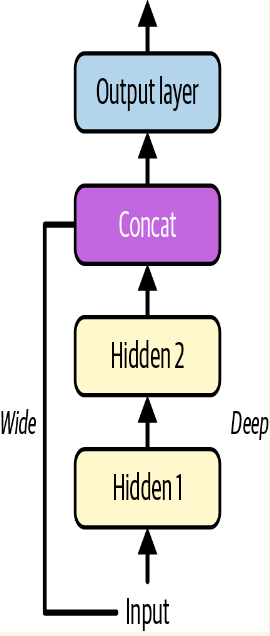

In [ ]:
class WideAndDeep(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features, 50),
        nn.ReLU(),
        nn.Linear(50, 40),
        nn.ReLU(),
    )

    self.output_layer = nn.Linear(40 + n_features, 1)

  def forward(self, X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X,deep_output], dim=1)
    return self.output_layer(wide_and_deep)

In [ ]:
[i for i in WideAndDeep(8).children()]

[Sequential(
   (0): Linear(in_features=8, out_features=50, bias=True)
   (1): ReLU()
   (2): Linear(in_features=50, out_features=40, bias=True)
   (3): ReLU()
 ),
 Linear(in_features=48, out_features=1, bias=True)]

In [ ]:
[i for i in WideAndDeep(8).named_children()]

[('deep_stack',
  Sequential(
    (0): Linear(in_features=8, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )),
 ('output_layer', Linear(in_features=48, out_features=1, bias=True))]

In [ ]:
torch.manual_seed(42)
model =WideAndDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
mse= nn.MSELoss()

In [ ]:
class WideAndDeepV2(nn.Module):
  def __init__(self, n_features):
    super().__init__()

    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), # X_deep = X[:, 2:]
        nn.ReLU(),
        nn.Linear(50, 40),
        nn.ReLU()
        )

    self.output_layer = nn.Linear(40 + 5, 1)      # 5 comes from wide


  def forward(self, X):
    X_wide = X[:, :5]
    X_deep = X[:, 2:]


    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim=1)

    return self.output_layer(wide_and_deep)

In [ ]:
torch.manual_seed(42)
model = WideAndDeepV2(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss:1.4311
Epoch 2/20, Loss:0.6245
Epoch 3/20, Loss:0.5740
Epoch 4/20, Loss:0.5462
Epoch 5/20, Loss:0.5301
Epoch 6/20, Loss:0.5140
Epoch 7/20, Loss:0.5042
Epoch 8/20, Loss:0.4956
Epoch 9/20, Loss:0.4890
Epoch 10/20, Loss:0.4818
Epoch 11/20, Loss:0.4774
Epoch 12/20, Loss:0.4707
Epoch 13/20, Loss:0.4704
Epoch 14/20, Loss:0.4637
Epoch 15/20, Loss:0.4619
Epoch 16/20, Loss:0.4571
Epoch 17/20, Loss:0.4561
Epoch 18/20, Loss:0.4522
Epoch 19/20, Loss:0.4505
Epoch 20/20, Loss:0.4470


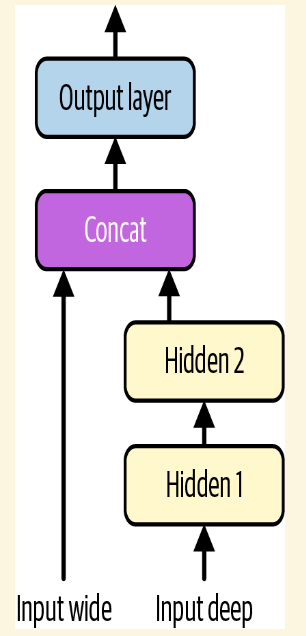


In [ ]:
class WideAndDeepV3(nn.Module):
  def __init__(self, n_features):
    super().__init__()

    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), nn.ReLU(),   # 6 features left
        nn.Linear(50, 40), nn.ReLU()
    )
    self.output_layer = nn.Linear(40 + 5, 1)   # 5 comes from wide

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim=1)

    return self.output_layer(wide_and_deep)

In [ ]:
print("X_test (wide) ölçüsü:", X_test[:, :5].shape)
print("X_test (deep) ölçüsü:", X_test[:, 2:].shape)
print("y_test ölçüsü:", y_test.shape)

X_test (wide) ölçüsü: torch.Size([4128, 5])
X_test (deep) ölçüsü: torch.Size([4128, 6])
y_test ölçüsü: torch.Size([4128, 1])


In [ ]:
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)

train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32, shuffle=True)
test_loader_wd = DataLoader(test_data_wd, batch_size=32, shuffle=True)

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    total_loss = 0.
    for X_batch_wide, X_batch_deep, y_batch in train_loader:
      X_batch_wide, X_batch_deep, y_batch = X_batch_wide.to(device), X_batch_deep.to(device), y_batch.to(device)
      y_pred = model(X_batch_wide, X_batch_deep)
      loss = criterion(y_pred, y_batch)
      total_loss = total_loss + loss
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss:{mean_loss:.4f}')

In [ ]:
torch.manual_seed(42)
learning_rate= 0.02
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse=nn.MSELoss()
train(model, optimizer, mse, train_loader_wd, n_epochs)

Epoch 1/20, Loss:0.6582
Epoch 2/20, Loss:0.5260
Epoch 3/20, Loss:0.5113
Epoch 4/20, Loss:0.4570
Epoch 5/20, Loss:0.4440
Epoch 6/20, Loss:0.4184
Epoch 7/20, Loss:0.4008
Epoch 8/20, Loss:0.3932
Epoch 9/20, Loss:0.3850
Epoch 10/20, Loss:0.3779
Epoch 11/20, Loss:0.4226
Epoch 12/20, Loss:0.3662
Epoch 13/20, Loss:0.4217
Epoch 14/20, Loss:0.3615
Epoch 15/20, Loss:0.3657
Epoch 16/20, Loss:0.3487
Epoch 17/20, Loss:0.4103
Epoch 18/20, Loss:0.3493
Epoch 19/20, Loss:0.3523
Epoch 20/20, Loss:0.3399


In [ ]:
class WideAndDeepDataset(torch.utils.data.Dataset):
  def __init__(self, X_wide, X_deep, y):
    self.X_wide = X_wide
    self.X_deep = X_deep
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
    return input_dict, self.y[idx]


In [ ]:
train_data_named = WideAndDeepDataset(X_wide = X_train[:, :5], X_deep = X_train[:, 2:], y=y_train)
valid_data_named = WideAndDeepDataset(X_wide = X_valid[:, :5], X_deep = X_valid[:, 2:], y=y_valid)
test_data_named = WideAndDeepDataset(X_wide = X_test[:, :5], X_deep = X_test[:, 2:], y=y_test)

train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs, plot_loss=False):
  losses = []
  for epoch in range(n_epochs):
    for inputs, y_batch in train_loader:
      inputs = {name: X.to(device) for name, X in inputs.items()}
      y_batch = y_batch.to(device)
      y_pred = model(X_wide=inputs['X_wide'], X_deep=inputs['X_deep'])
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    losses.append(loss.item())
    print(f'Epoch {epoch + 1}/{n_epochs}, Loss: {loss}')

  if plot_loss:
    plt.figure(figsize=(8, 5))
    plt.title('Learning Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(range(n_epochs),losses);

In [ ]:
lr = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
mse = nn.MSELoss()

In [ ]:
model = model.to(device)

Epoch 1/20, Loss: 0.10731085389852524
Epoch 2/20, Loss: 0.38299620151519775
Epoch 3/20, Loss: 0.3597482740879059
Epoch 4/20, Loss: 0.5768805742263794
Epoch 5/20, Loss: 0.6069876551628113
Epoch 6/20, Loss: 0.37188997864723206
Epoch 7/20, Loss: 0.1957985907793045
Epoch 8/20, Loss: 0.5975985527038574
Epoch 9/20, Loss: 0.6699158549308777
Epoch 10/20, Loss: 0.20689770579338074
Epoch 11/20, Loss: 0.39058151841163635
Epoch 12/20, Loss: 0.21398165822029114
Epoch 13/20, Loss: 0.22715239226818085
Epoch 14/20, Loss: 0.3045274317264557
Epoch 15/20, Loss: 0.20766954123973846
Epoch 16/20, Loss: 0.28493353724479675
Epoch 17/20, Loss: 0.20144854485988617
Epoch 18/20, Loss: 0.28237617015838623
Epoch 19/20, Loss: 0.4115617573261261
Epoch 20/20, Loss: 0.22227241098880768


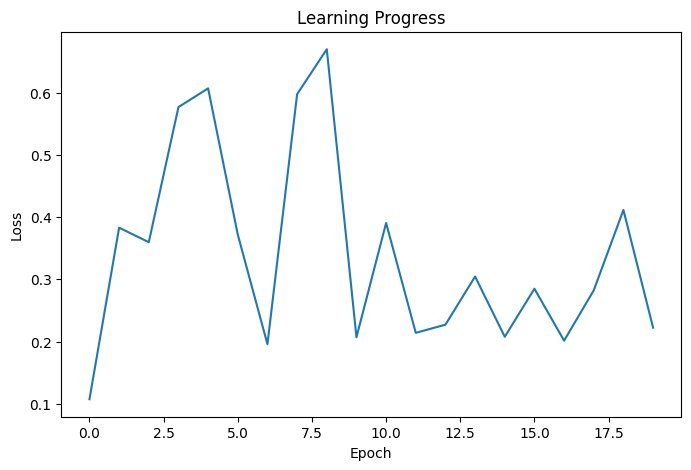

In [ ]:
train(model, optimizer, mse, train_loader_named, 20, True)

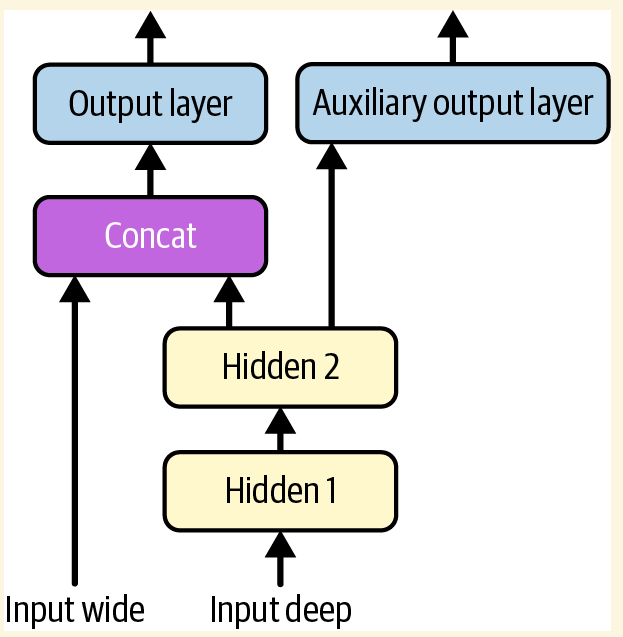

In [ ]:
class WideAndDeepV4(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(6, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU()
    )
    self.output_layer = nn.Linear(40 + 5, 1)
    self.aux_output_layer = nn.Linear(40, 1)

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    concat = torch.concat([X_wide, deep_output], dim=1)
    main_output = self.output_layer(concat)
    aux_output = self.aux_output_layer(deep_output)

    return main_output, aux_output


In [ ]:
model = WideAndDeepV4(n_features)

In [ ]:
model

WideAndDeepV4(
  (deep_stack): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=45, out_features=1, bias=True)
  (aux_output_layer): Linear(in_features=40, out_features=1, bias=True)
)

In [ ]:
!pip install torchviz graphviz

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    for inputs, y_batch in train_loader:
      y_pred, y_pred_aux = model(**inputs)
      main_loss = criterion(y_pred, y_batch)
      aux_loss = criterion(y_pred_aux, y_batch)
      loss = 0.8 * main_loss + 0.2 * aux_loss

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    print(f'Epoch {epoch + 1}/{n_epochs}, Loss: {loss}')

In [ ]:
lr = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
mse = nn.MSELoss()

In [ ]:
train(model, optimizer, mse, train_loader_named, 20)

Epoch 1/20, Loss: 0.7852893471717834
Epoch 2/20, Loss: 0.8818755745887756
Epoch 3/20, Loss: 0.7116300463676453
Epoch 4/20, Loss: 0.3703238070011139
Epoch 5/20, Loss: 0.7072381973266602
Epoch 6/20, Loss: 0.4420678913593292
Epoch 7/20, Loss: 0.4788414537906647
Epoch 8/20, Loss: 0.5787625312805176
Epoch 9/20, Loss: 0.3428381085395813
Epoch 10/20, Loss: 0.31148117780685425
Epoch 11/20, Loss: 0.43537434935569763
Epoch 12/20, Loss: 0.38986527919769287
Epoch 13/20, Loss: 0.37626177072525024
Epoch 14/20, Loss: 0.8637886643409729
Epoch 15/20, Loss: 0.4202684462070465
Epoch 16/20, Loss: 0.49291306734085083
Epoch 17/20, Loss: 0.4673042893409729
Epoch 18/20, Loss: 0.4772793650627136
Epoch 19/20, Loss: 0.689836859703064
Epoch 20/20, Loss: 0.5419751405715942


In [ ]:
X_wide_graph = [i for i in train_loader_named][:1][0][0]['X_wide']
X_deep_graph = [i for i in train_loader_named][:1][0][0]['X_deep']

In [ ]:

import torch
from torchviz import make_dot
import torchvision.models as models

In [ ]:
model.eval()

batch_size = 1
X_wide = torch.zeros(batch_size, 5)
X_deep = torch.zeros(batch_size, 6)

y_pred, y_aux = model(X_wide, X_deep)

dot = make_dot(
    (y_pred + y_aux).sum(),
    params=dict(model.named_parameters())
)

dot.format = "png"
dot.render("wide_and_deep_graph")


'wide_and_deep_graph.png'

# Let's do some VISION👁

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

In [ ]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [ ]:
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=False, download=True, transform=toTensor)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 164kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.7MB/s]


In [ ]:
torch.manual_seed(42)

In [ ]:
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data,
                                                       [55_000, 5_000])

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)


In [ ]:
X_sample, y_sample = train_data[0]

In [ ]:
X_sample.dtype

torch.float32

In [ ]:
X_sample.shape

torch.Size([1, 28, 28])

In [ ]:
train_and_valid_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2),
        nn.ReLU(),
        nn.Linear(n_hidden2, n_classes),
    )

  def forward(self, X):
    return self.mlp(X)

In [ ]:
torch.manual_seed(42)

In [ ]:
model = ImageClassifier(n_inputs=28*28, n_hidden1=300, n_hidden2=100, n_classes=10)
model = model.to(device)
xentropy = nn.CrossEntropyLoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    print(f'Epoch: {epoch+1}/{n_epochs}, Loss: {loss}')

In [ ]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.002)

In [ ]:
train(model, optimizer, xentropy, train_loader, 20)

Epoch: 1/20, Loss: 0.34854817390441895
Epoch: 2/20, Loss: 0.4583101272583008
Epoch: 3/20, Loss: 0.2988094985485077
Epoch: 4/20, Loss: 0.04827139899134636
Epoch: 5/20, Loss: 0.2699546217918396
Epoch: 6/20, Loss: 0.2914935052394867
Epoch: 7/20, Loss: 0.4269780218601227
Epoch: 8/20, Loss: 0.28903719782829285
Epoch: 9/20, Loss: 0.3793589174747467
Epoch: 10/20, Loss: 0.33987924456596375
Epoch: 11/20, Loss: 0.3464600741863251
Epoch: 12/20, Loss: 0.18229252099990845
Epoch: 13/20, Loss: 0.1410140097141266
Epoch: 14/20, Loss: 0.10774862766265869
Epoch: 15/20, Loss: 0.3295397162437439
Epoch: 16/20, Loss: 0.19080352783203125
Epoch: 17/20, Loss: 0.09922081232070923
Epoch: 18/20, Loss: 0.2718295753002167
Epoch: 19/20, Loss: 0.0633695125579834
Epoch: 20/20, Loss: 0.11204659938812256


In [ ]:
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

In [ ]:
model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [ ]:
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)

with torch.no_grad():
  y_pred_logits = model(X_new)

y_pred = y_pred_logits.argmax(dim=1)
y_pred

tensor([7, 4, 2], device='cuda:0')

In [ ]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

In [ ]:
X_new.shape

torch.Size([3, 1, 28, 28])

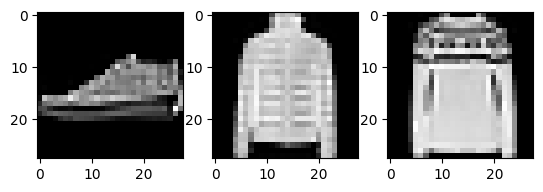

In [ ]:
for i in range(X_new.shape[0]):
  plt.subplot(1, 3, i +1)
  plt.imshow(X_new[i, 0, :, :].cpu().numpy(), cmap='gray')

In [ ]:
import torch.nn.functional as F

In [ ]:
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0020, 0.0000, 0.7440, 0.0000,
         0.2550],
        [0.0000, 0.0000, 0.0360, 0.0000, 0.9590, 0.0000, 0.0050, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0000, 0.8030, 0.0000, 0.1320, 0.0000, 0.0640, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [ ]:
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, 4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)


tensor([[0.7440, 0.2550, 0.0020, 0.0000],
        [0.9590, 0.0360, 0.0050, 0.0000],
        [0.8030, 0.1320, 0.0640, 0.0010]], device='cuda:0')

In [ ]:
y_top4_indices


tensor([[7, 9, 5, 3],
        [4, 2, 6, 3],
        [2, 4, 6, 0]], device='cuda:0')

# Optimizing Models

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.1 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-07-14 16:45:47,488] A new study created in memory with name: no-name-e2bacaa2-53a8-4b1a-9e00-12354cd3d021


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6326
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 9/10, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424


[I 2026-07-14 16:48:38,332] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6229, valid metric: 0.7338
Epoch 2/10, train loss: 0.6108, train metric: 0.7841, valid metric: 0.7992
Epoch 3/10, train loss: 0.5203, train metric: 0.8169, valid metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8302, valid metric: 0.8310
Epoch 5/10, train loss: 0.4557, train metric: 0.8404, valid metric: 0.8352
Epoch 6/10, train loss: 0.4387, train metric: 0.8460, valid metric: 0.8442
Epoch 7/10, train loss: 0.4240, train metric: 0.8512, valid metric: 0.8408
Epoch 8/10, train loss: 0.4123, train metric: 0.8566, valid metric: 0.8514
Epoch 9/10, train loss: 0.3998, train metric: 0.8601, valid metric: 0.8532


[I 2026-07-14 16:51:14,094] Trial 1 finished with value: 0.8547999858856201 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8547999858856201.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, valid metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, valid metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, valid metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, valid metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, valid metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, valid metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, valid metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, valid metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, valid metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, valid metric: 0.2918


[I 2026-07-14 16:56:27,833] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, valid metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, valid metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, valid metric: 0.6978
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, valid metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, valid metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, valid metric: 0.7906
Epoch 6/10, train loss: 0.5687, train metric: 0.8053, valid metric: 0.8050
Epoch 7/10, train loss: 0.5386, train metric: 0.8164, valid metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, valid metric: 0.8214
Epoch 9/10, train loss: 0.4988, train metric: 0.8279, valid metric: 0.8220


[I 2026-07-14 16:59:04,917] Trial 4 finished with value: 0.8220000267028809 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, valid metric: 0.8092


In [ ]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [ ]:
study.best_value

0.8547999858856201

In [ ]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    best_validation_accuracy = 0.0
    for epoch in range(n_epochs):
        history = train2(model, optimizer, xentropy, accuracy, train_loader,
                         valid_loader, n_epochs=1)
        validation_accuracy = max(history["valid_metrics"])
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
        trial.report(validation_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_validation_accuracy

In [ ]:
objective_with_data = lambda trial: objective(
    trial, train_loader=train_loader, valid_loader=valid_loader)

In [ ]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader,
                              valid_loader=valid_loader)

In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="maximize", sampler=sampler,
                            pruner=pruner)
study.optimize(objective_with_data, n_trials=20)

In [ ]:
study.best_value

In [ ]:
study.best_params

In [ ]:
torch.save(model, "my_fashion_mnist.pt")


In [ ]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)
loaded_model.eval()


In [ ]:
y_pred_logits = loaded_model(X_new)


In [ ]:
torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")


In [ ]:
model.state_dict()

In [ ]:
type(model.state_dict())

In [ ]:
new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10)
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

In [ ]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10,
    }
}
torch.save(model_data, "my_fashion_mnist_model.pt")

In [ ]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()






> # Compile And Optimize the model



In [ ]:
torchscript_model = torch.jit.trace(model, X_new)

In [ ]:
torchscript_model = torch.jit.script(model)

In [ ]:
optimized_model = torch.jit.optimize_for_inference(torchscript_model)

In [ ]:
optimized_model.save("my_fashion_mnist_torchscript.pt")

In [ ]:
loaded_torchscript_model = torch.jit.load("my_fashion_mnist_torchscript.pt")

In [ ]:
y_pred_logits = loaded_torchscript_model(X_new)
y_pred_logits

In [ ]:
compiled_model = torch.compile(model)

In [ ]:
if device == "cuda":
    y_pred_logits = compiled_model(X_new)